In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import config as c

In [2]:
sns.set_context("notebook")
sns.set_style("whitegrid")
sns.set_theme(

    rc={"font.family": "sans-serif", "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],

        "axes.labelsize": 13,
        "axes.titlesize": 15,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 11,
        "legend.title_fontsize": 12,

        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.linewidth": 1.0})

Now, the name of the file doesn't start with "ELM19", because the dataset has already been preprocessed and it not equal to original sourced from Poziomska et. al.

In [6]:
head = f'{c.META_DIR}'
filename_1 = f'{head}/exams.csv'
filename_2 = f'{head}/sites.csv'
filename_3 = f'{head}/longitudinal.csv'

## exams

In [7]:
data = pd.read_csv(filename_1)

In [8]:
data.head()

,site,patient_id,exam_id,age,age_group,female,pathology
0,S00,P32423,20220512-151756-{195a4196-0111-4fa5-a0a2-951e8...,47.0,46-55,1,1
1,S00,P28507,20220512-163015-{f7af3b95-1afd-4de4-8b7e-78c46...,46.9,46-55,1,0
2,S00,P28506,20220512-162932-{408352a4-978b-4b42-bff2-62db7...,40.6,36-45,0,1
3,S00,P28505,20220512-162946-{3ad3c86b-3d61-440e-81df-b74fd...,36.9,36-45,0,1
4,S00,P28504,20220512-163006-{6e353308-dcd5-4cdd-9ae3-c3fa8...,52.6,46-55,0,1


In [9]:
#!pip install dython

https://shakedzy.xyz/dython/modules/nominal/

To investigate the correlation between metadata features a smart wrapper function of various correlation calculation methods (associations from dython.nominal) must be implemented.

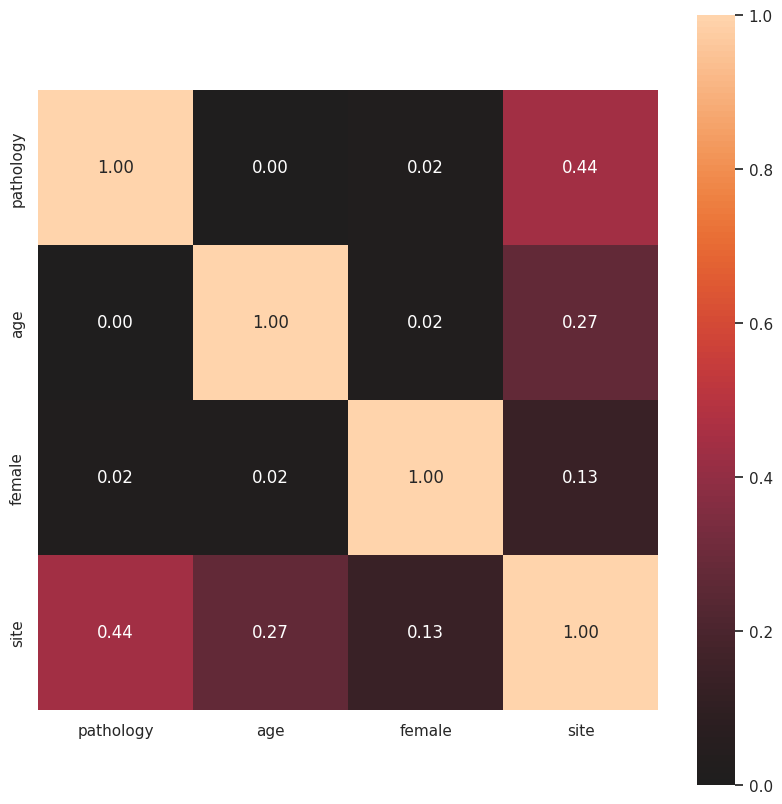

{'corr':            pathology       age    female      site
 pathology   1.000000  0.000873  0.020162  0.438164
 age         0.000873  1.000000  0.021045  0.272309
 female      0.020162  0.021045  1.000000  0.133176
 site        0.438164  0.272309  0.133176  1.000000,
 'ax': <Axes: >}

In [10]:
from dython.nominal import associations
cols = ["pathology", "age", "female", "site"]

associations(
    data[cols],
    nominal_columns=["pathology", "female", "site"],
    numerical_columns=["age"],
    figsize = (10,10)
)

The most concerning correlation, is a very high one between site & pathology.

In [11]:
LABEL_PALETTE = {'0': "#4A90E2", '1': "#E06666"}
SEX_PALETTE = {'0': "#00A878", '1': "#9B51E0"}

bins = [0, 1]
label_labels = ['Norm', 'Pathology']
sex_labels = ['Male', 'Female']

In [12]:
order = ['16-25', '26-35', '36-45','46-55', '56-65']

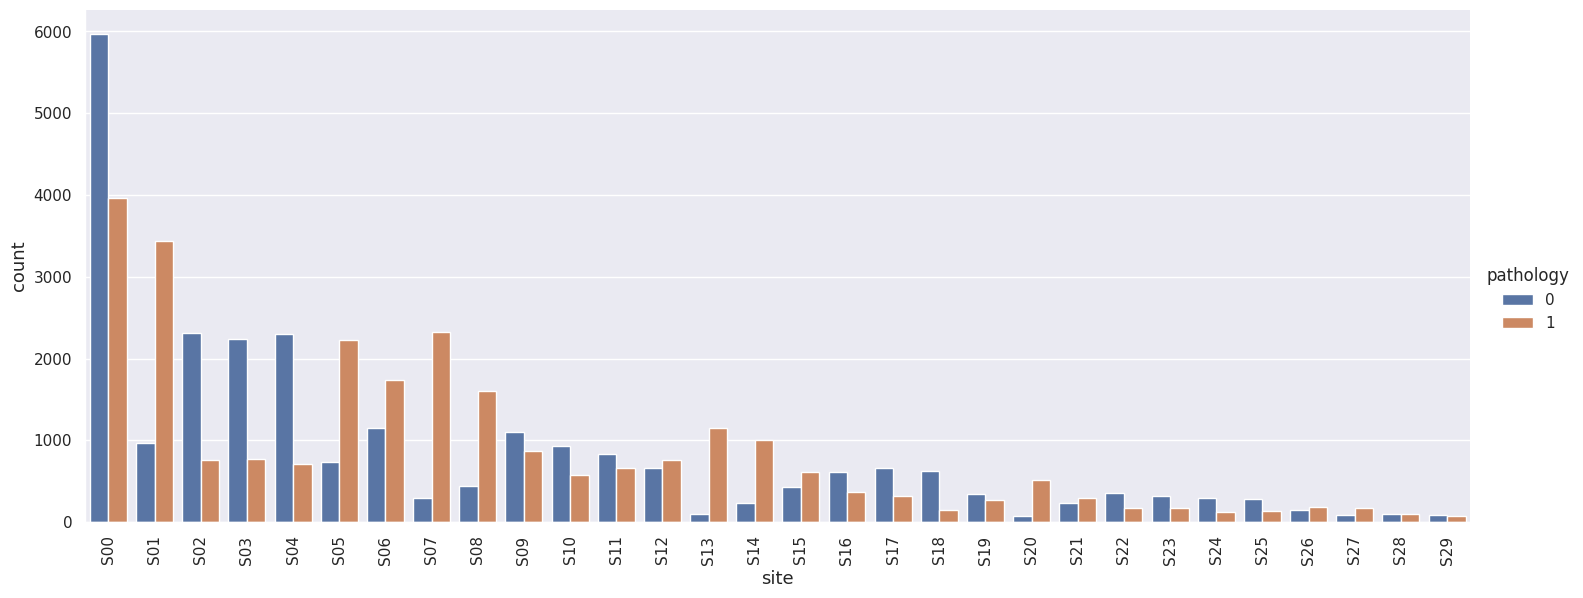

In [13]:
g = sns.catplot(x='site',
                hue='pathology',
                data=data,
                kind='count',
                order=data['site'].value_counts().index,
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Even though the whole dataset is well-balanced in terms of control and pathological clinical groups, the inter-site distribution is very unequal, so different sites should definitely not be treated as seperate datasets (before balancing with respective weights and/or subsampling from the majority group).

This is a huge problem with heterogenous datasets and demand harmonization, not to overshadow any underlying neural patterns. Let's try to build naive-nauroscreener, the logistic regressor only on the metadata. This is a dignostic step to later compare with deep learning x functional connectivity (eeg) approach.

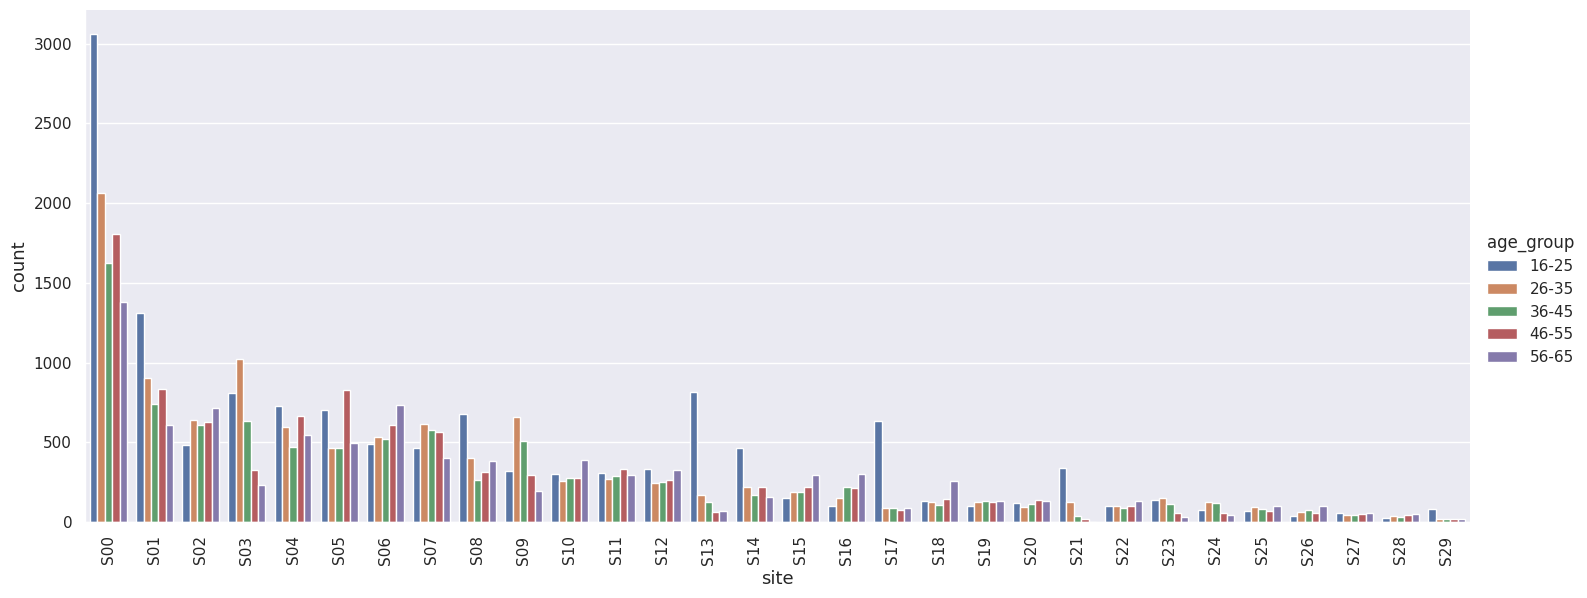

In [14]:
g = sns.catplot(x='site',
                hue='age_group',
                hue_order= order,
                data=data,
                kind='count',
                order=data['site'].value_counts().index,
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Some sites can be also easily disingushed by majority age group (young: S00, S13, S17). Age is a tricky confunder, because it is assumed to be correlated with health condition.

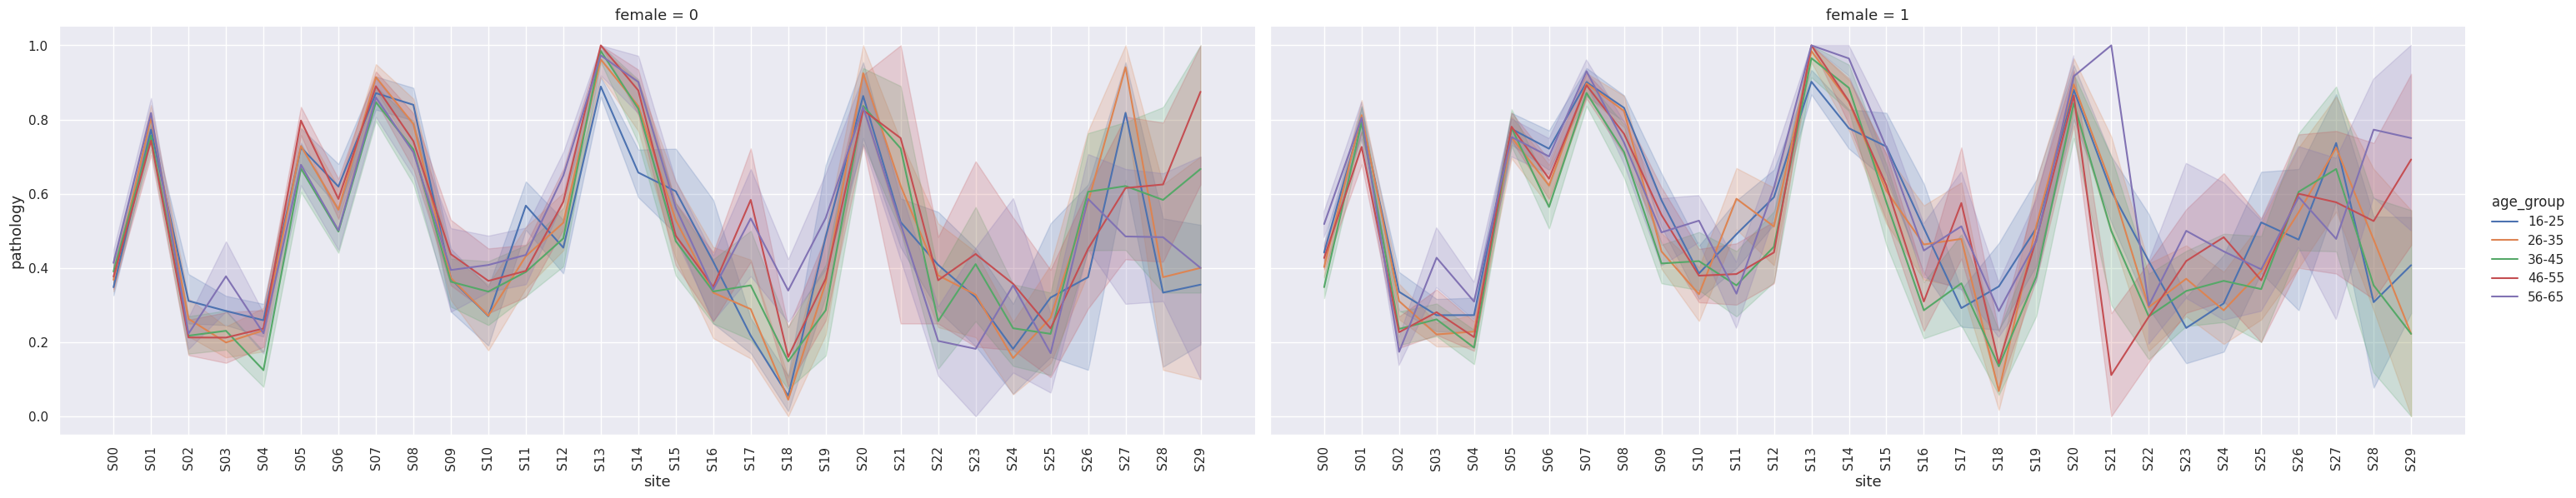

In [15]:
g = sns.relplot(x='site',
                y = "pathology",
                hue='age_group',
                hue_order= order,
                data=data,
                col = "female",
                kind='line',
                height=6,
                aspect=2.5)

g.set_xticklabels(rotation=90)

Potentially, S21 is a candidate for removal. Huge correlation between age and label.

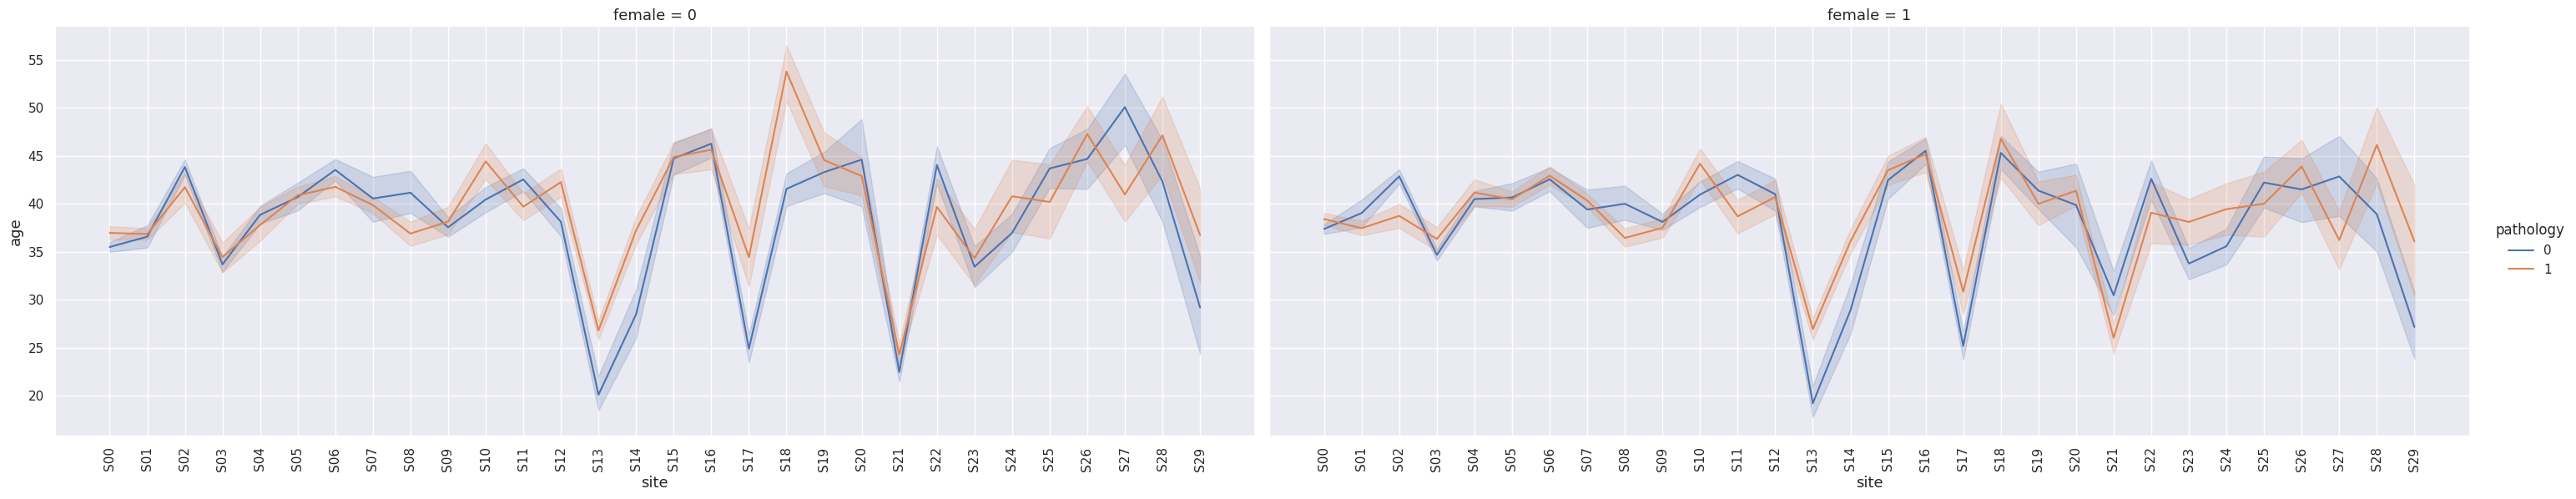

In [16]:
g = sns.relplot(x='site',
                y = "age",
                hue='pathology',
                data=data,
                kind='line',
                col = "female",
                height=6,
                aspect=2.5,
                sort = True)

g.set_xticklabels(rotation=90)

## sites

In [17]:
data = pd.read_csv(filename_2)
data_long = pd.read_csv(filename_3)

In [18]:
data.head()

,site,#exams,#unique_subs,#unique_long_subs
0,S00,9930,8184,948
1,S01,4401,3700,504
2,S02,3073,2470,354
3,S03,3017,1570,177
4,S04,3003,2062,410


In [19]:
data_long.head()

,site,patient_id,n_exams
0,S00,P00004,2
1,S00,P00005,2
2,S00,P00006,2
3,S00,P00009,17
4,S00,P00013,2


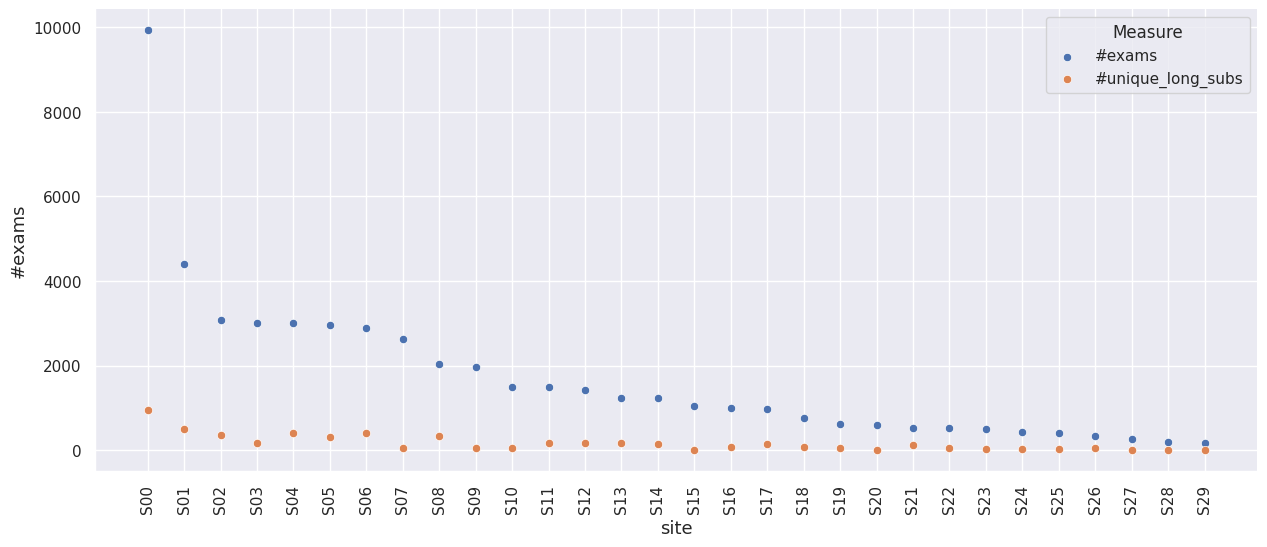

In [20]:
fig, ax = plt.subplots(figsize=(15, 6))

order = data['site'].value_counts().index

sns.scatterplot(
    data=data, x='site', y='#exams',
    ax=ax, label='#exams'
)

sns.scatterplot(
    data=data, x='site', y='#unique_long_subs',
    ax=ax, label='#unique_long_subs'
)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(order, rotation=90)
ax.legend(title='Measure')

In [21]:
data_long

,site,patient_id,n_exams
0,S00,P00004,2
1,S00,P00005,2
2,S00,P00006,2
3,S00,P00009,17
4,S00,P00013,2
...,...,...,...
4863,S29,P22790,2
4864,S29,P29277,2
4865,S29,P29283,2
4866,S29,P29284,2


Text(0.5, 1.05, 'Distribution of longitudinal patients within each site')

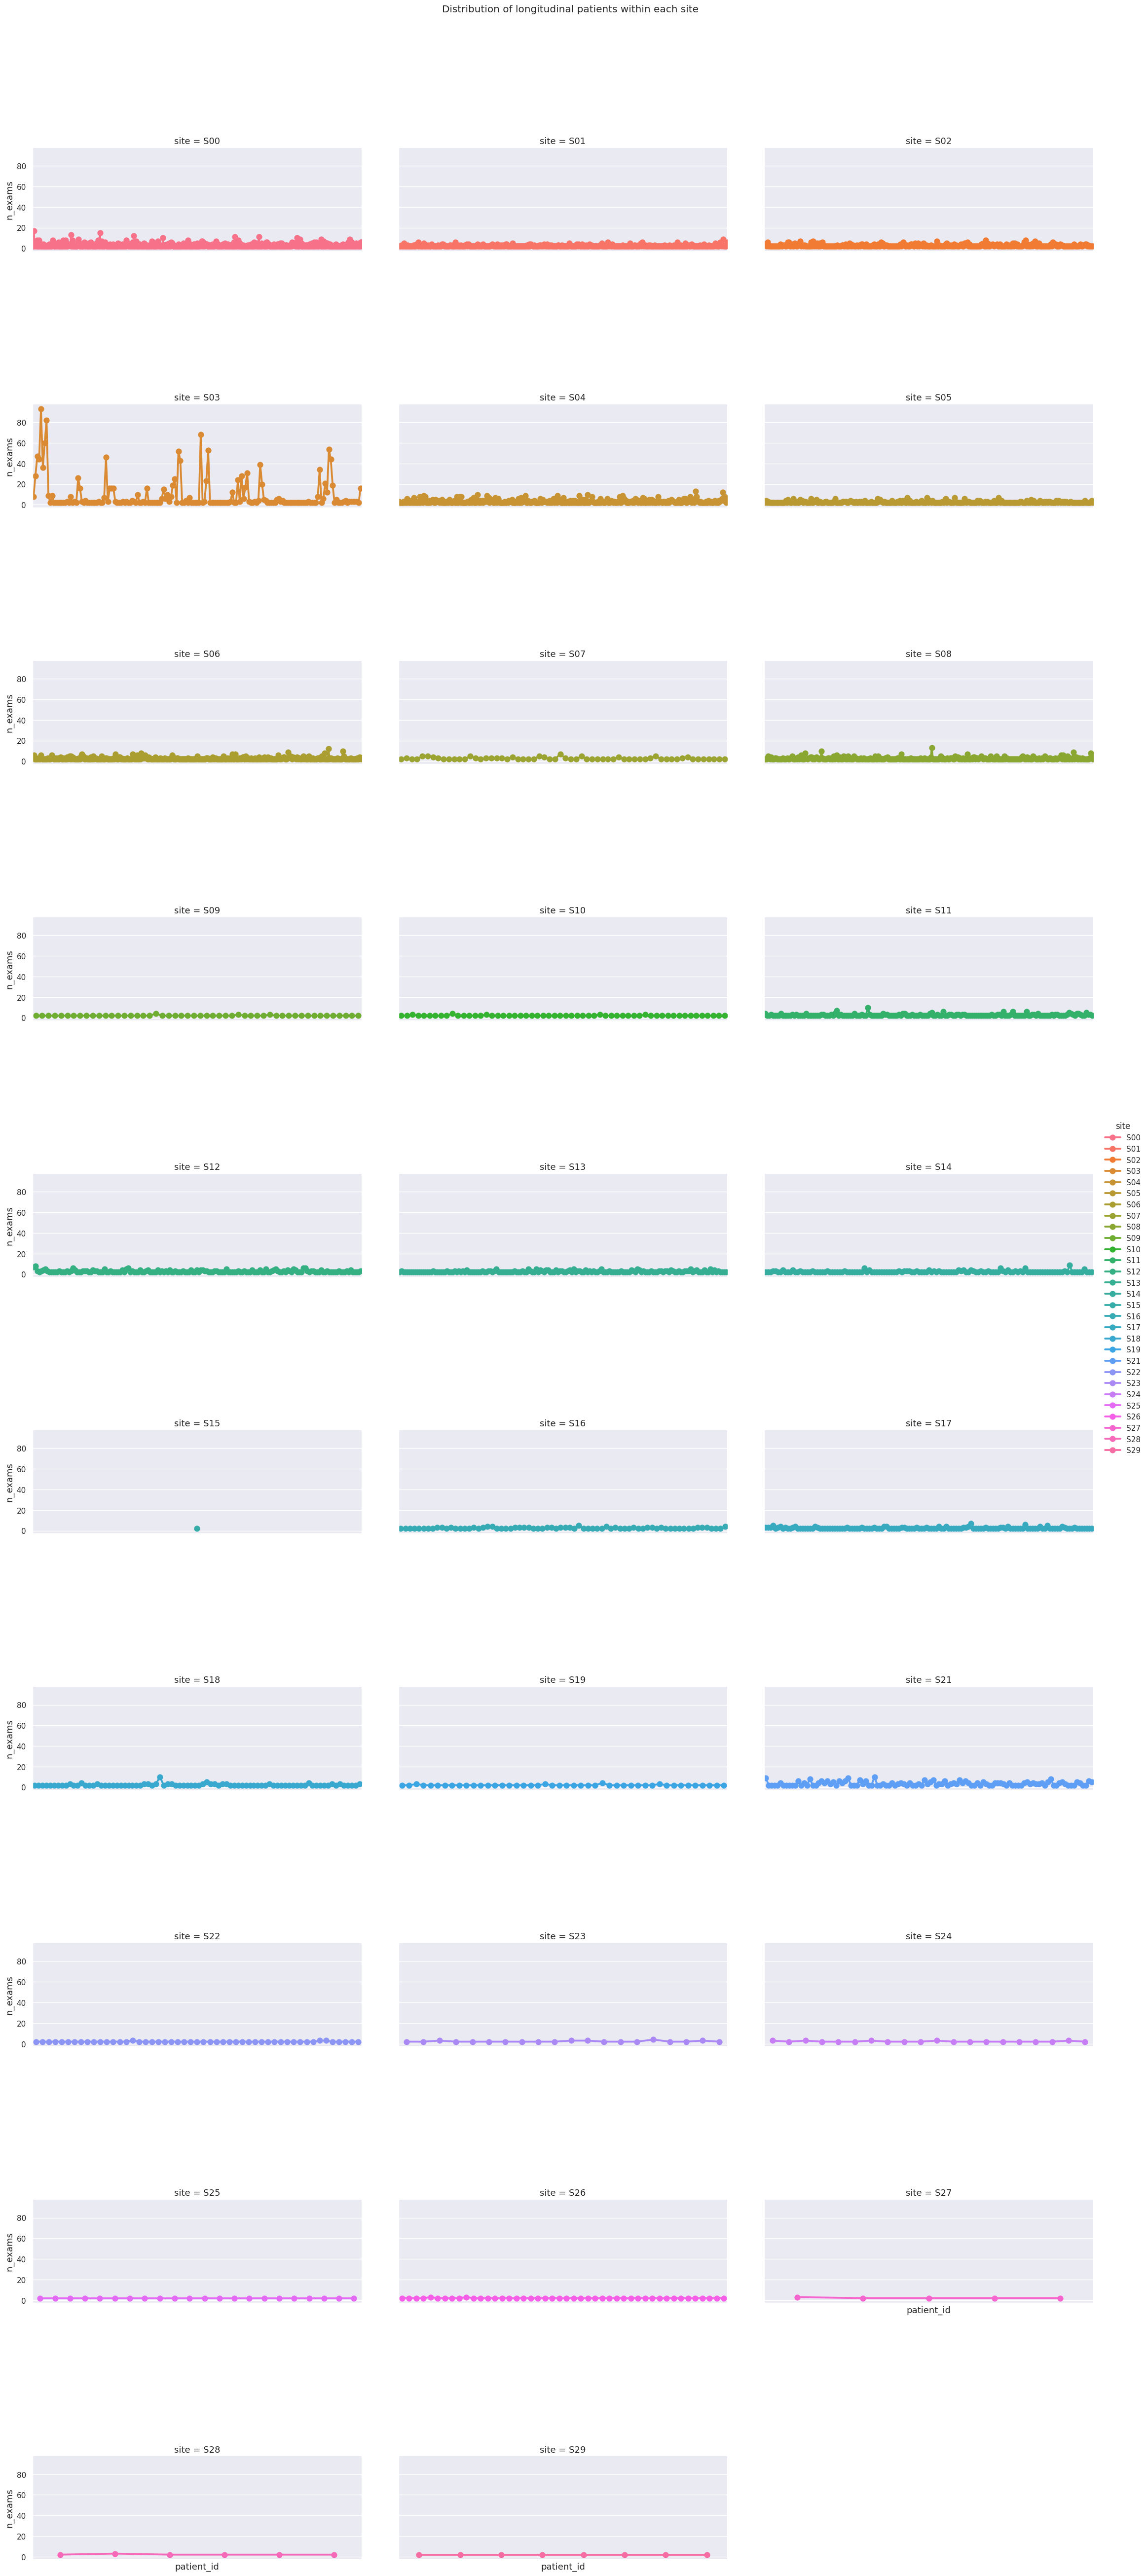

In [23]:
g = sns.catplot(
    data=data_long,
    x='patient_id',
    y='n_exams',
    kind='point',
    col="site", 
    col_wrap = 3,      
    hue="site",       
    sharex=False,# drop empty
    height=5,         
    aspect=1.5)

g.set(xticks=[])
g.figure.suptitle("Distribution of longitudinal patients within each site", y=1.05)